In [5]:
import sys
import subprocess
import os
try:
    import seaborn
except ImportError:
    print("seaborn yukleniyor...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import copy
import json

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"cihaz: {device}")

DATA_DIR = r'C:\Users\user\Desktop\DerinProjem\garbage-dataset' 

if not os.path.exists(DATA_DIR):
    print("HATA: dosya yolu yanlis, duzeltilmesi lazim!")
else:
    print("dosya yolu tamam.")

cihaz: cuda
dosya yolu tamam.


In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
    classes = full_dataset.classes
    print(f"siniflar: {classes}")
    print(f"toplam resim: {len(full_dataset)}")
except Exception as e:
    print("veri okunurken hata oldu.")
    raise e

# veriyi dengeli bolmek icin stratify kullaniyorum
# %70 train, %15 val, %15 test
train_idx, temp_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.3, 
    stratify=full_dataset.targets,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5, 
    stratify=[full_dataset.targets[i] for i in temp_idx],
    random_state=42
)

train_data = Subset(full_dataset, train_idx)
val_data = Subset(full_dataset, val_idx)
test_data = Subset(full_dataset, test_idx)


BATCH_SIZE = 32
# windows'ta hata vermesin diye num_workers 0
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"train: {len(train_data)}, val: {len(val_data)}, test: {len(test_data)}")

siniflar: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
toplam resim: 19762
train: 13833, val: 2964, test: 2965


In [7]:
class ShallowMLP(nn.Module):
    def __init__(self, num_classes):
        super(ShallowMLP, self).__init__()
        # giris boyutu: 224x224x3 = 150528
        self.flatten = nn.Flatten()
        
        self.layers = nn.Sequential(
            
            nn.Linear(224 * 224 * 3, 2048), 
            nn.ReLU(),
            nn.Dropout(0.3), # ezberlemeyi azaltmak icin %30
        
            nn.Linear(2048, 512), 
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

In [8]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / total, correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / total, correct / total

In [9]:
print("en iyi learning rate araması(random search)")

# logaritmik dagilimda 5 farkli lr deniyorum
lr_candidates = [10**(-np.random.uniform(3, 5)) for _ in range(5)]
best_lr = None
best_val_acc = 0.0


SEARCH_EPOCHS = 5 

for i, lr in enumerate(lr_candidates):
    print(f"deneme {i+1} -> lr: {lr:.6f}")
    
    temp_model = ShallowMLP(len(classes)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    
    for epoch in range(SEARCH_EPOCHS):
        _, _ = train_epoch(temp_model, train_loader, criterion, optimizer)
        _, val_acc = validate(temp_model, val_loader, criterion)
    
    print(f"   sonuc val acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_lr = lr

print(f"\nsecilen en iyi lr: {best_lr:.6f}")

en iyi learning rate araması(random search)
deneme 1 -> lr: 0.000178
   sonuc val acc: 0.3991
deneme 2 -> lr: 0.000013
   sonuc val acc: 0.5111
deneme 3 -> lr: 0.000034
   sonuc val acc: 0.4933
deneme 4 -> lr: 0.000063
   sonuc val acc: 0.4760
deneme 5 -> lr: 0.000487
   sonuc val acc: 0.3600

secilen en iyi lr: 0.000013


In [10]:
print("final model egitimine baslanıyor...")

final_model = ShallowMLP(len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
scheduler = CosineAnnealingLR(optimizer, T_max=15) 


EPOCHS = 30
patience = 5
patience_counter = 0
best_model_wts = copy.deepcopy(final_model.state_dict())
best_acc = 0.0


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    t_loss, t_acc = train_epoch(final_model, train_loader, criterion, optimizer)
    v_loss, v_acc = validate(final_model, val_loader, criterion)
    
    scheduler.step()
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    
    print(f"epoch {epoch+1} | loss: {t_loss:.4f} acc: {t_acc:.4f} | val_loss: {v_loss:.4f} val_acc: {v_acc:.4f}")
    
    
    if v_acc > best_acc:
        best_acc = v_acc
        best_model_wts = copy.deepcopy(final_model.state_dict())
        torch.save(final_model.state_dict(), "best_mlp_model.pth")
        patience_counter = 0 
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print("early stopping calisti, egitimi durduruyorum.")
        break

with open('training_history.json', 'w') as f:
    json.dump(history, f)
print("egitim verileri kaydedildi.")

final_model.load_state_dict(best_model_wts)
print("en iyi model yuklendi.")

final model egitimine baslanıyor...
epoch 1 | loss: 1.8851 acc: 0.3651 | val_loss: 1.6235 val_acc: 0.4430
epoch 2 | loss: 1.6964 acc: 0.4186 | val_loss: 1.5320 val_acc: 0.4781
epoch 3 | loss: 1.6136 acc: 0.4481 | val_loss: 1.5028 val_acc: 0.4939
epoch 4 | loss: 1.5424 acc: 0.4709 | val_loss: 1.4537 val_acc: 0.5091
epoch 5 | loss: 1.4685 acc: 0.4990 | val_loss: 1.4122 val_acc: 0.5226
epoch 6 | loss: 1.4263 acc: 0.5094 | val_loss: 1.3799 val_acc: 0.5428
epoch 7 | loss: 1.3724 acc: 0.5247 | val_loss: 1.3556 val_acc: 0.5520
epoch 8 | loss: 1.3294 acc: 0.5397 | val_loss: 1.3350 val_acc: 0.5520
epoch 9 | loss: 1.2779 acc: 0.5616 | val_loss: 1.2960 val_acc: 0.5746
epoch 10 | loss: 1.2339 acc: 0.5801 | val_loss: 1.2891 val_acc: 0.5698
epoch 11 | loss: 1.1962 acc: 0.5903 | val_loss: 1.2586 val_acc: 0.5867
epoch 12 | loss: 1.1466 acc: 0.6119 | val_loss: 1.2480 val_acc: 0.5833
epoch 13 | loss: 1.1388 acc: 0.6127 | val_loss: 1.2403 val_acc: 0.5938
epoch 14 | loss: 1.1191 acc: 0.6169 | val_loss: 1.

In [12]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

if 'history' not in locals():
    with open('training_history.json', 'r') as f:
        history = json.load(f)

epochs_range = range(1, len(history['train_loss']) + 1)
print("veriler hazir, grafiklere geciyorum...")

veriler hazir, grafiklere geciyorum...


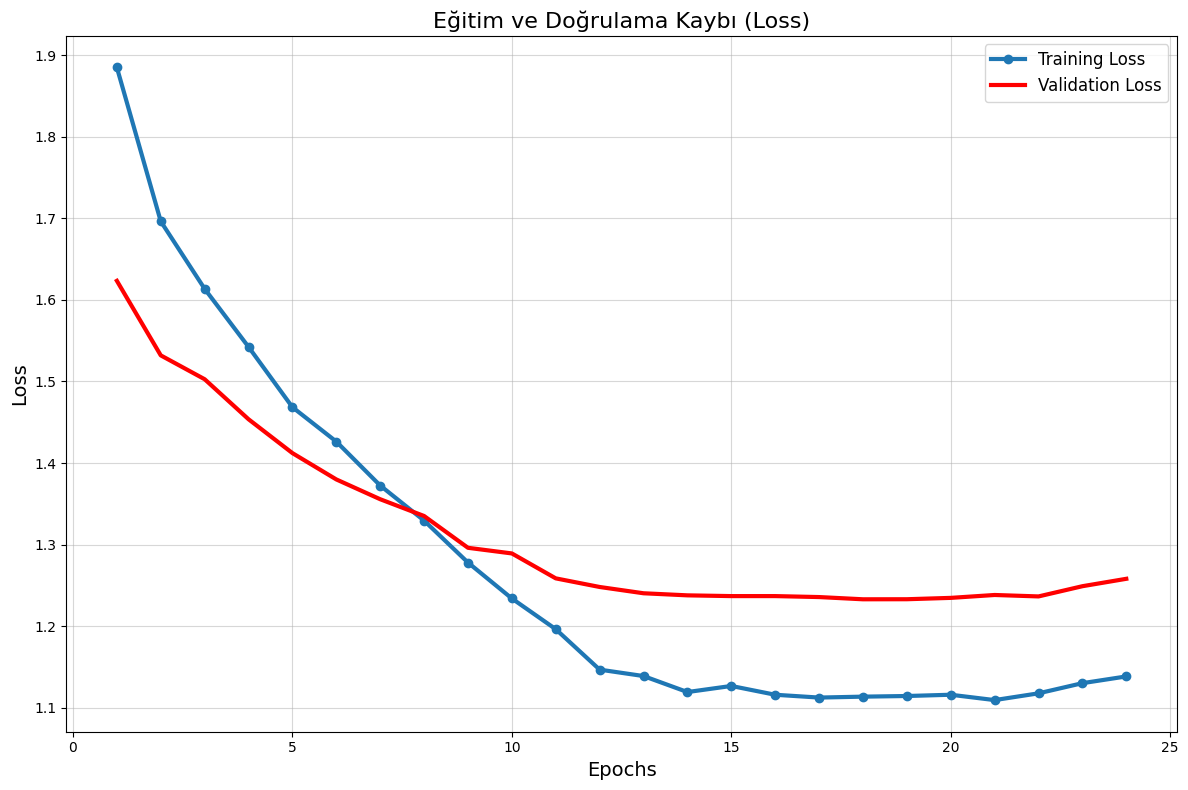

In [13]:
# --- LOSS GRAFIGI ---
plt.figure(figsize=(12, 8))
plt.plot(epochs_range, history['train_loss'], 'o-', linewidth=3, label='Training Loss')
plt.plot(epochs_range, history['val_loss'], 'r-', linewidth=3, label='Validation Loss')

plt.title('Eğitim ve Doğrulama Kaybı (Loss)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('grafik_loss.png', dpi=300) 
plt.show()

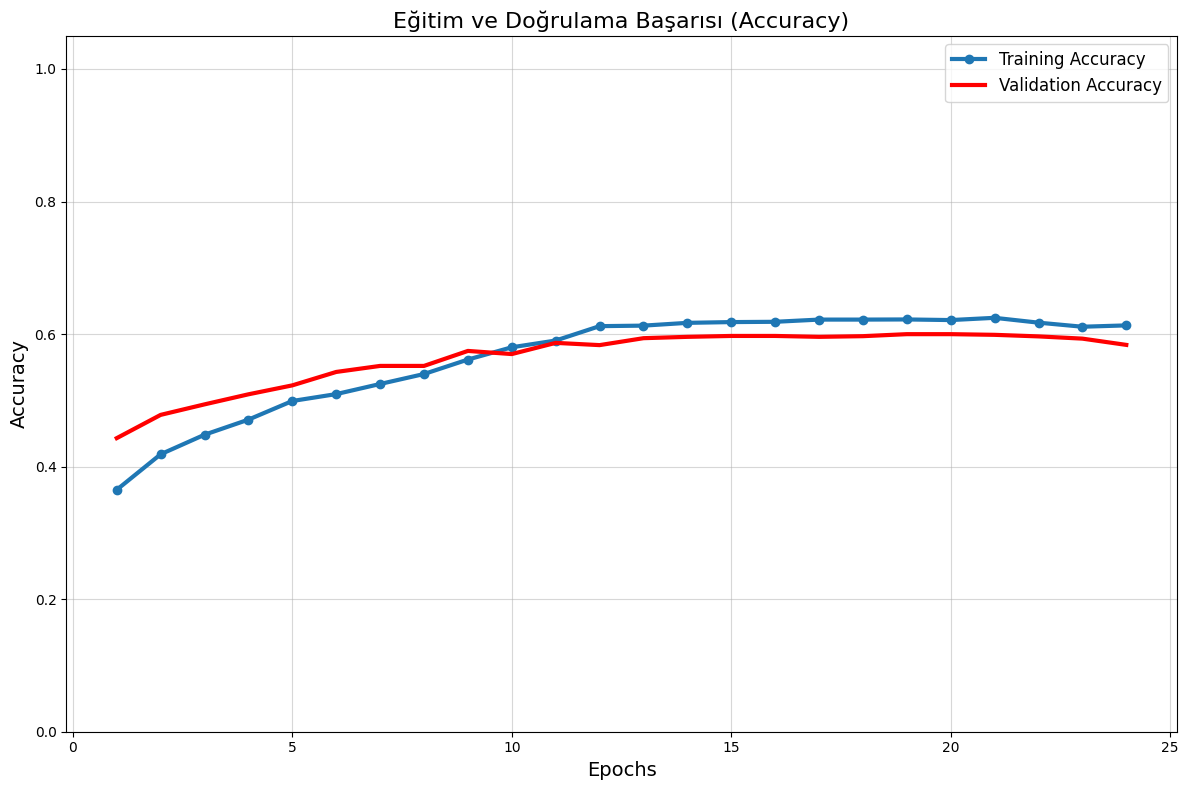

In [14]:
# --- ACCURACY GRAFIGI ---
plt.figure(figsize=(12, 8))
plt.plot(epochs_range, history['train_acc'], 'o-', linewidth=3, label='Training Accuracy')
plt.plot(epochs_range, history['val_acc'], 'r-', linewidth=3, label='Validation Accuracy')

plt.title('Eğitim ve Doğrulama Başarısı (Accuracy)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1.05) # 0 ile 1 arasina sabitledim
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('grafik_accuracy.png', dpi=300)
plt.show()

In [15]:
print("Test seti uzerinde tahminler yapiliyor...")

final_model.eval()
test_preds = []
test_labels = []
test_probs = [] 

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        _, predicted = torch.max(outputs, 1)
        
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

Test seti uzerinde tahminler yapiliyor...


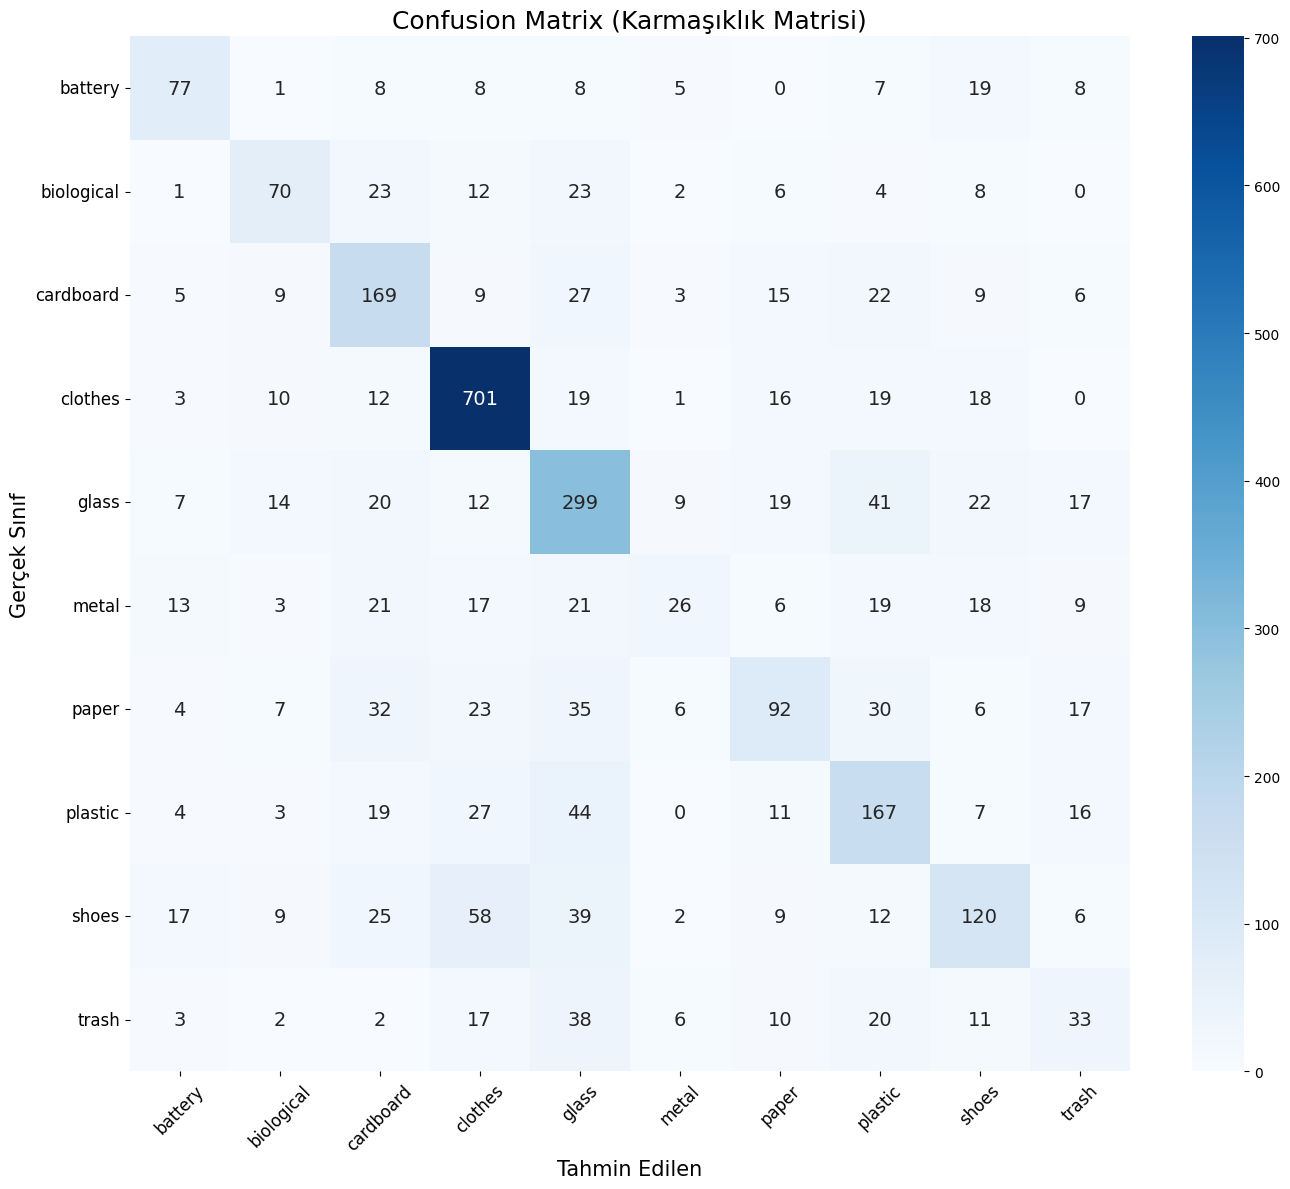

In [16]:
# --- CONFUSION MATRIX ---
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 14})

plt.xlabel('Tahmin Edilen', fontsize=15)
plt.ylabel('Gerçek Sınıf', fontsize=15)
plt.title('Confusion Matrix (Karmaşıklık Matrisi)', fontsize=18)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig('grafik_confusion_matrix.png', dpi=300)
plt.show()

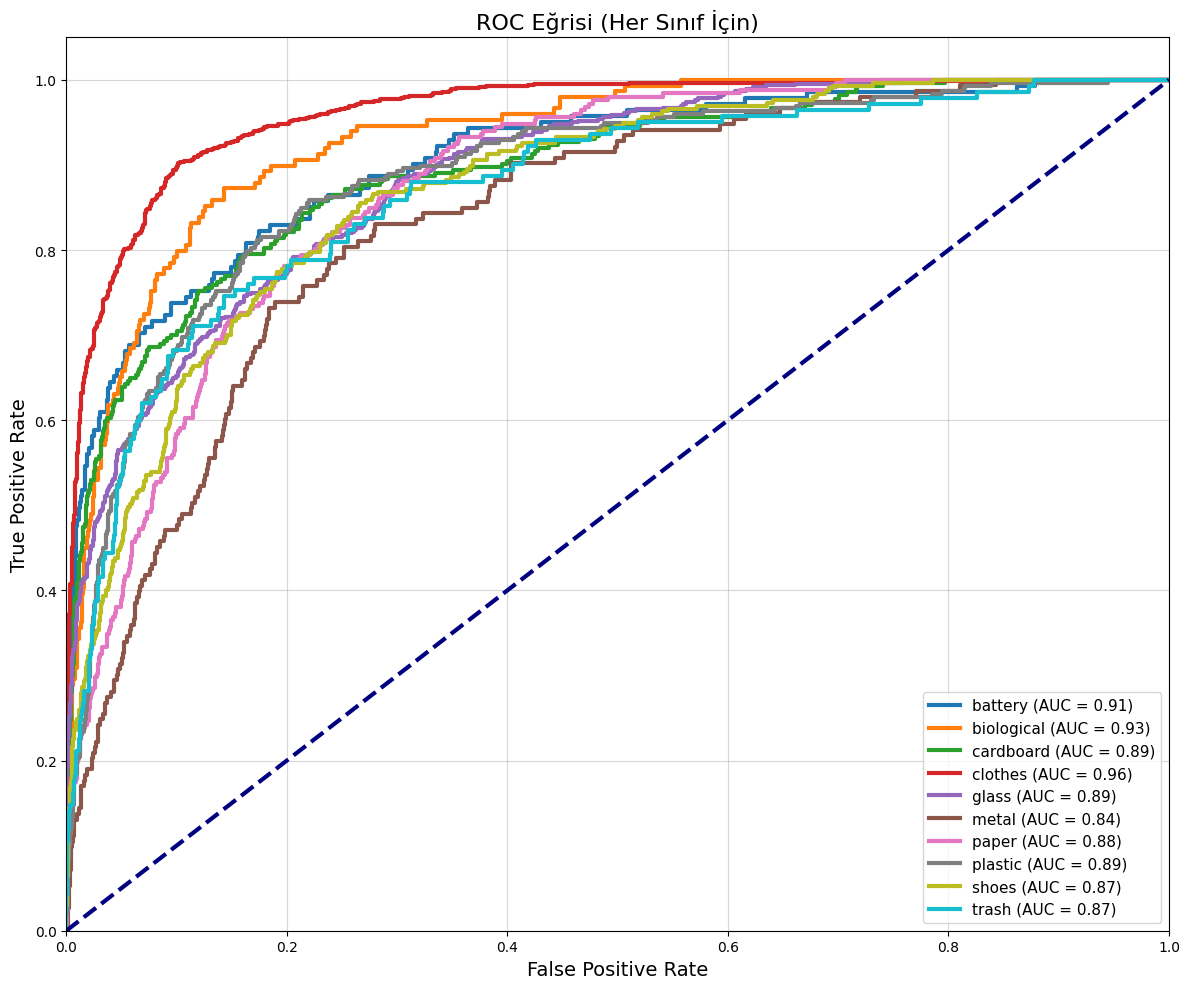

In [17]:
# --- ROC EGRISI ---
try:
    test_labels_bin = label_binarize(test_labels, classes=range(len(classes)))
    test_probs_np = np.array(test_probs)
    
    plt.figure(figsize=(12, 10)) 
    
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(test_labels_bin[:, i], test_probs_np[:, i])
        roc_auc = auc(fpr, tpr)
       
        plt.plot(fpr, tpr, lw=3, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('ROC Eğrisi (Her Sınıf İçin)', fontsize=16)
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('grafik_roc_curve.png', dpi=300)
    plt.show()
    
except Exception as e:
    print(f"Hata: {e}")

In [18]:
print("-" * 60)
print("-" * 60)
acc = accuracy_score(test_labels, test_preds)
print(f"GENEL TEST DOGRULUGU (Accuracy): %{acc*100:.2f}")
print("-" * 60)
print(classification_report(test_labels, test_preds, target_names=classes))

------------------------------------------------------------
------------------------------------------------------------
GENEL TEST DOGRULUGU (Accuracy): %59.16
------------------------------------------------------------
              precision    recall  f1-score   support

     battery       0.57      0.55      0.56       141
  biological       0.55      0.47      0.51       149
   cardboard       0.51      0.62      0.56       274
     clothes       0.79      0.88      0.83       799
       glass       0.54      0.65      0.59       460
       metal       0.43      0.17      0.24       153
       paper       0.50      0.37      0.42       252
     plastic       0.49      0.56      0.52       298
       shoes       0.50      0.40      0.45       297
       trash       0.29      0.23      0.26       142

    accuracy                           0.59      2965
   macro avg       0.52      0.49      0.49      2965
weighted avg       0.58      0.59      0.58      2965



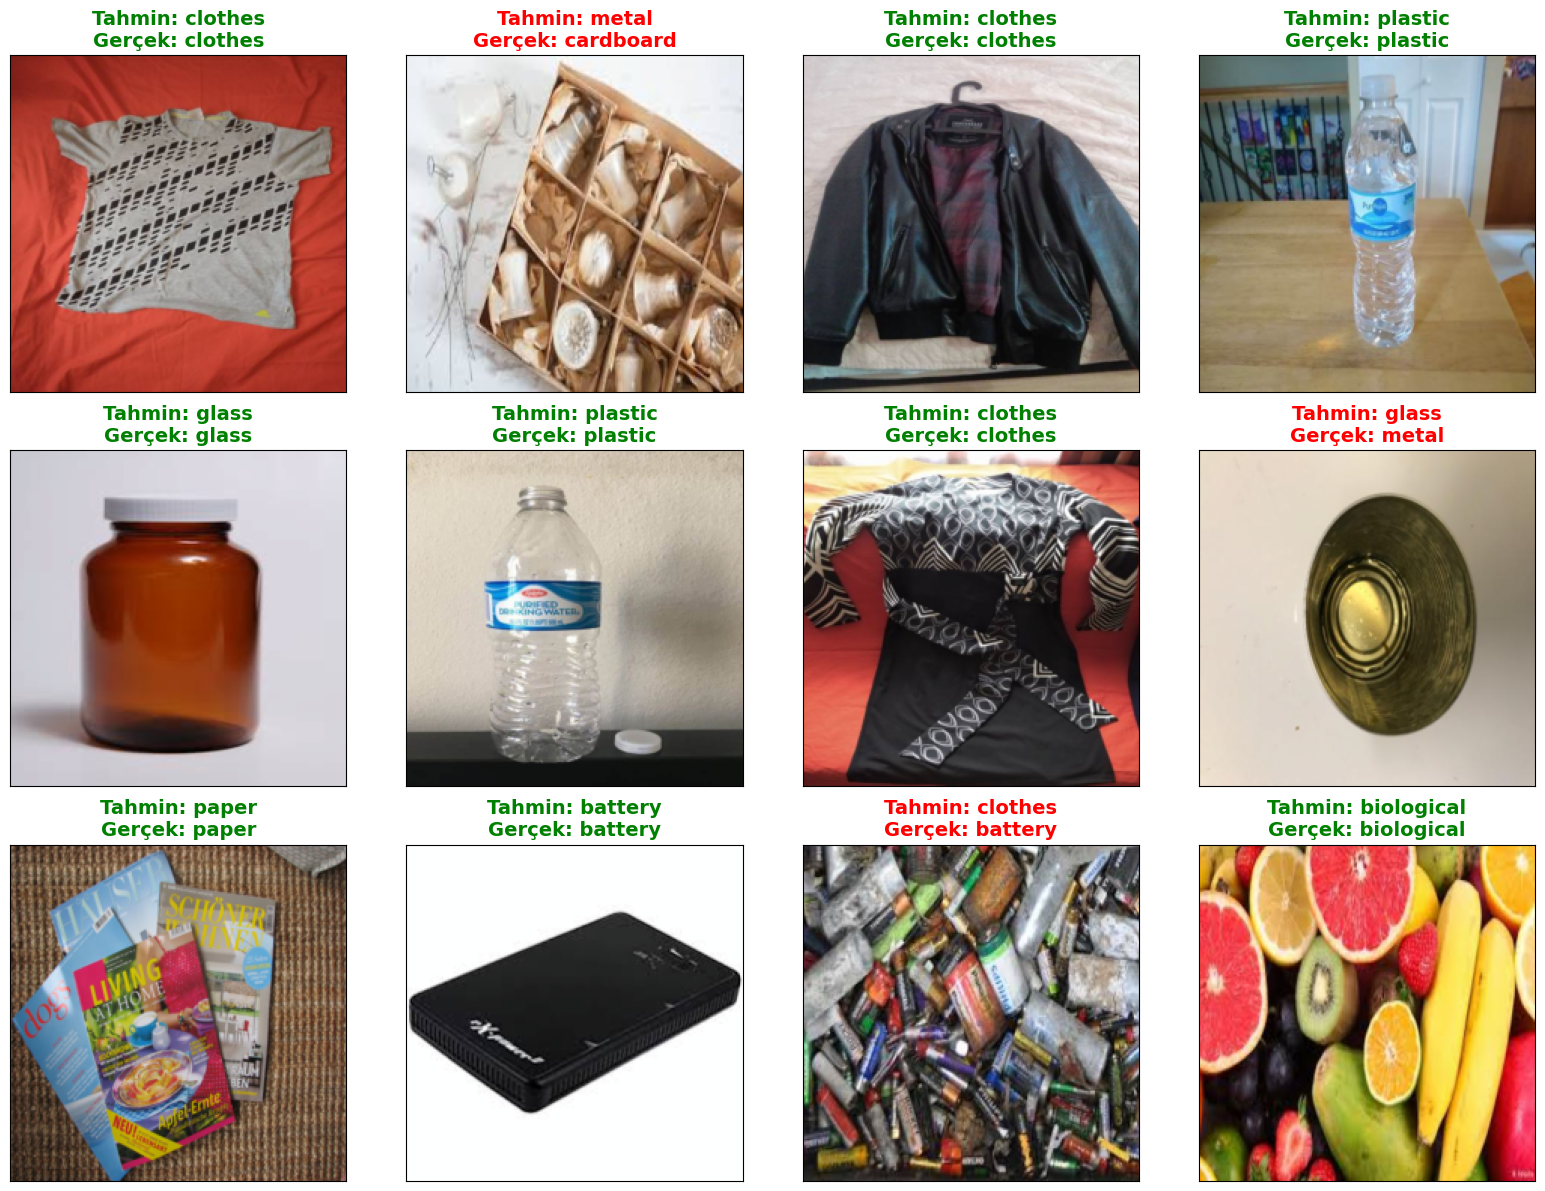

In [19]:
def visualize_predictions(model, loader, num_images=12):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)
    
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    
    
    images = images.cpu().numpy()
    preds = preds.cpu().numpy()
    labels = labels.cpu().numpy()
    
    
    fig = plt.figure(figsize=(16, 12))
    
    for i in range(num_images):
        ax = fig.add_subplot(3, 4, i+1, xticks=[], yticks=[])
        
       
        img = images[i].transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        color = 'green' if preds[i] == labels[i] else 'red'
        
        ax.set_title(f"Tahmin: {classes[preds[i]]}\nGerçek: {classes[labels[i]]}",
                     color=color, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('grafik_ornek_tahminler.png', dpi=300)
    plt.show()


visualize_predictions(final_model, test_loader, num_images=12)

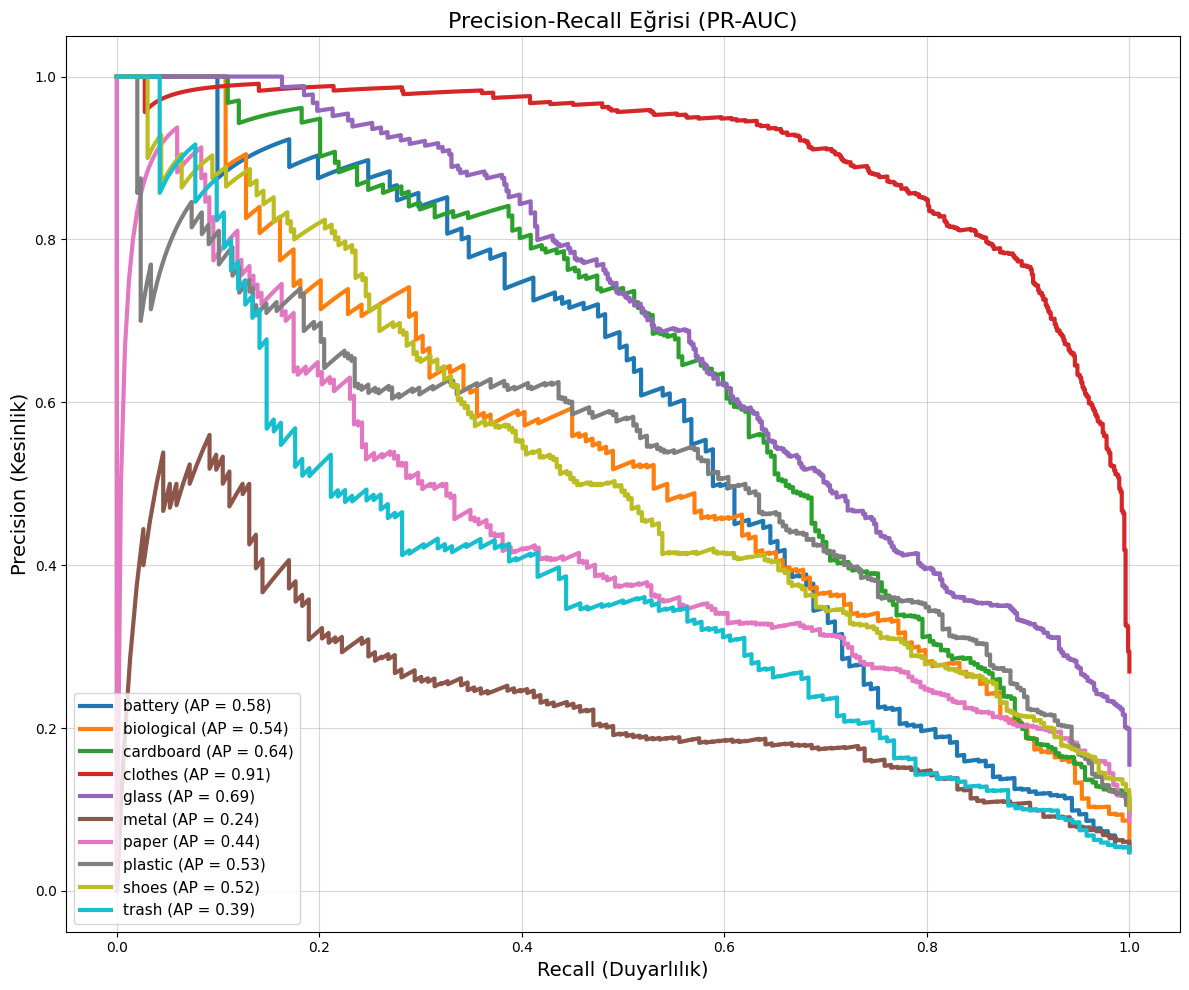

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- PRECISION-RECALL EGRISI ---
try:
    test_labels_bin = label_binarize(test_labels, classes=range(len(classes)))
    test_probs_np = np.array(test_probs)
    
    plt.figure(figsize=(12, 10))
    
    for i in range(len(classes)):
        precision, recall, _ = precision_recall_curve(test_labels_bin[:, i], test_probs_np[:, i])
        avg_precision = average_precision_score(test_labels_bin[:, i], test_probs_np[:, i])
        
        plt.plot(recall, precision, lw=3, label=f'{classes[i]} (AP = {avg_precision:.2f})')

    plt.xlabel('Recall (Duyarlılık)', fontsize=14)
    plt.ylabel('Precision (Kesinlik)', fontsize=14)
    plt.title('Precision-Recall Eğrisi (PR-AUC)', fontsize=16)
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(True, alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('grafik_pr_curve.png', dpi=300)
    plt.show()
    
except Exception as e:
    print(f"Hata: {e}")

C:\Users\user\AppData\Local\Temp\ipykernel_2896\532798215.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=class_counts, palette="viridis")


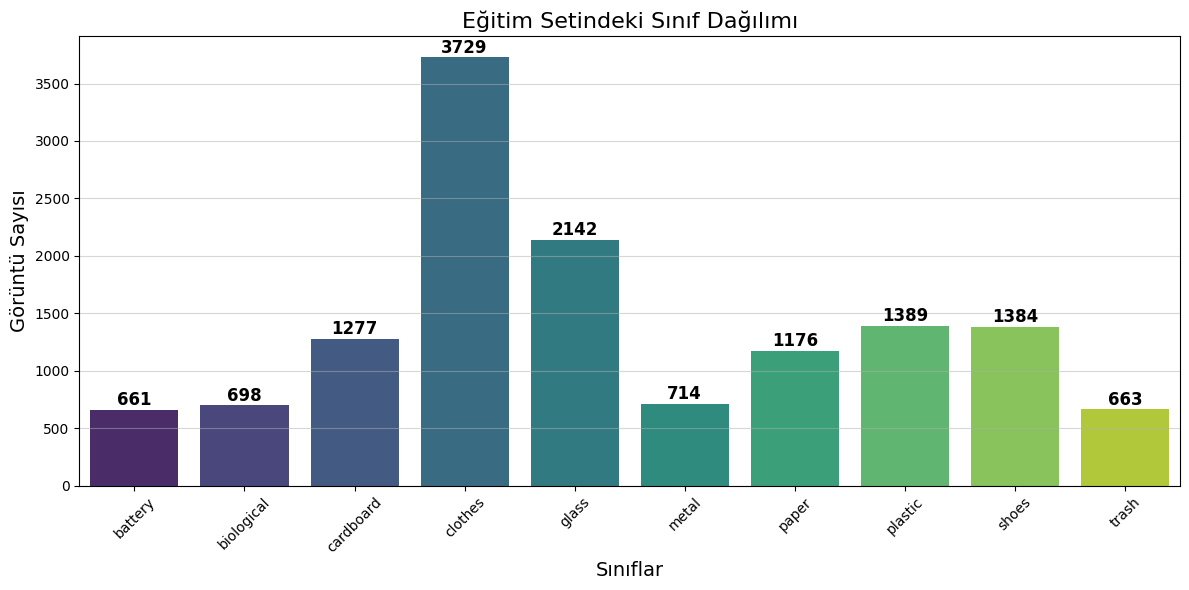

In [21]:
# --- SINIF DAGILIMI GRAFIGI ---
# train setindeki dagilima bakalim
train_labels_indices = [y for _, y in train_data]
class_counts = [train_labels_indices.count(i) for i in range(len(classes))]

plt.figure(figsize=(12, 6))
sns.barplot(x=classes, y=class_counts, palette="viridis")

plt.title('Eğitim Setindeki Sınıf Dağılımı', fontsize=16)
plt.xlabel('Sınıflar', fontsize=14)
plt.ylabel('Görüntü Sayısı', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)

for i, count in enumerate(class_counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('grafik_sinif_dagilimi.png', dpi=300)
plt.show()

Toplam 2965 test verisi icinde 1211 tane hata var.


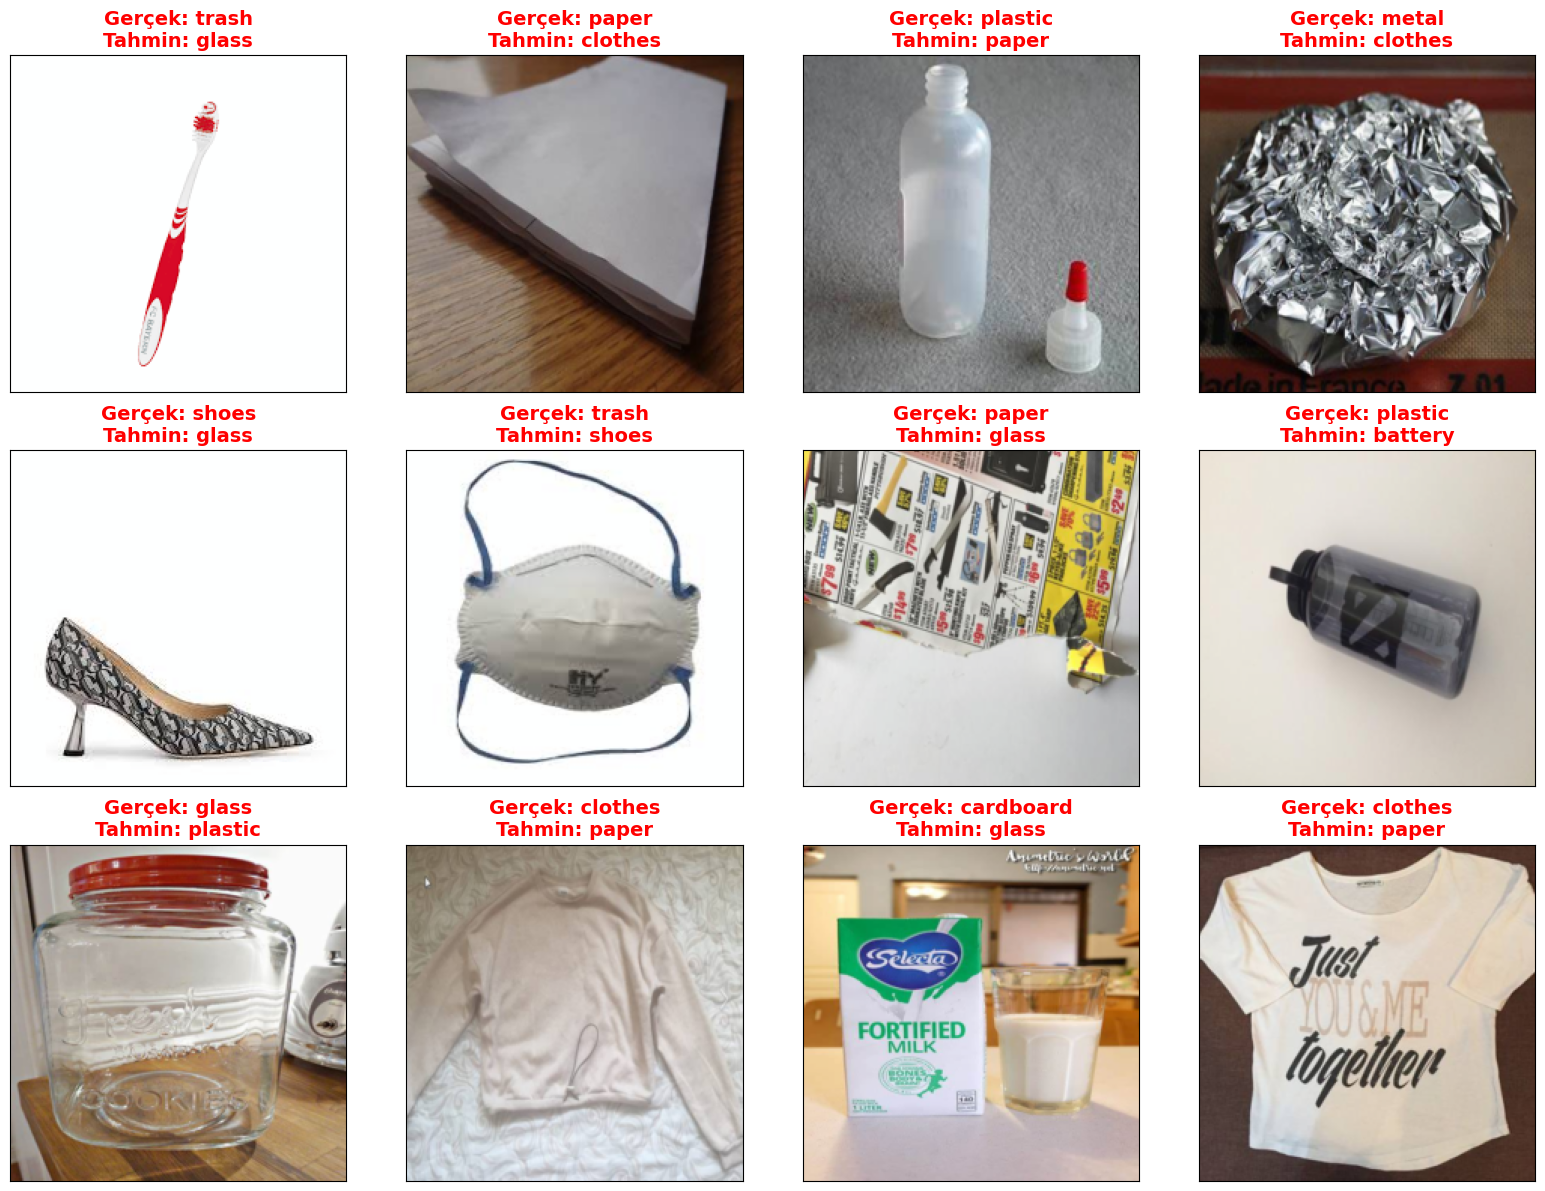

In [22]:
wrong_idx = np.where(np.array(test_preds) != np.array(test_labels))[0]

if len(wrong_idx) > 0:
    print(f"Toplam {len(test_labels)} test verisi icinde {len(wrong_idx)} tane hata var.")
    
    # rastgele 12 tane hatali ornek secelim
    selected_indices = np.random.choice(wrong_idx, min(12, len(wrong_idx)), replace=False)
    
    fig = plt.figure(figsize=(16, 12))
    
   
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i, idx in enumerate(selected_indices):
        ax = fig.add_subplot(3, 4, i+1, xticks=[], yticks=[])
        
        
        img_tensor, _ = test_data[idx]
        img = img_tensor.permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        true_class = classes[test_labels[idx]]
        pred_class = classes[test_preds[idx]]
        
        
        ax.set_title(f"Gerçek: {true_class}\nTahmin: {pred_class}", 
                     color='red', fontsize=14, fontweight='bold')
        
    plt.tight_layout()
    plt.savefig('grafik_hatali_tahminler.png', dpi=300)
    plt.show()
else:
    print("tebrikler! hic hata yok (veya test seti cok kucuk).")

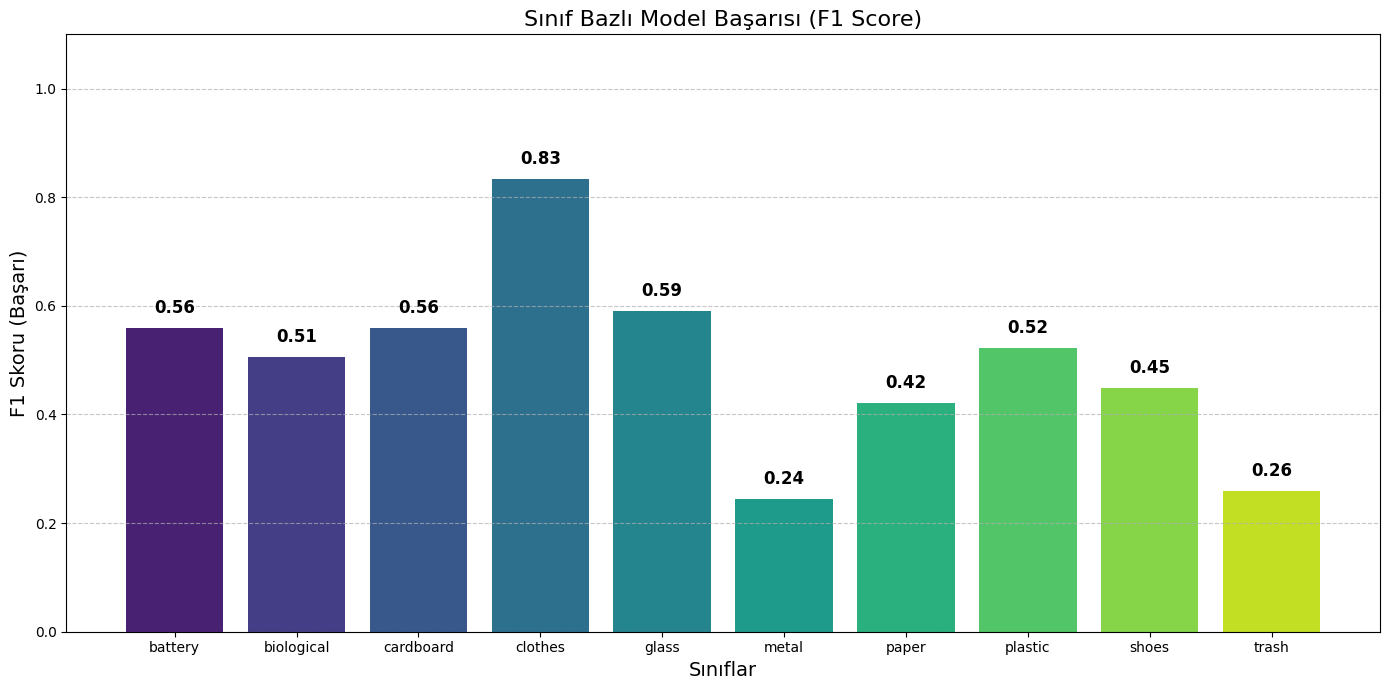

In [23]:
report_dict = classification_report(test_labels, test_preds, target_names=classes, output_dict=True)


class_names_list = []
f1_scores = []

for name in classes:
    class_names_list.append(name)
    f1_scores.append(report_dict[name]['f1-score'])


plt.figure(figsize=(14, 7))
colors = sns.color_palette("viridis", len(classes)) 
bars = plt.bar(class_names_list, f1_scores, color=colors)

plt.xlabel('Sınıflar', fontsize=14)
plt.ylabel('F1 Skoru (Başarı)', fontsize=14)
plt.title('Sınıf Bazlı Model Başarısı (F1 Score)', fontsize=16)
plt.ylim(0, 1.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('grafik_sinif_basarisi.png', dpi=300)
plt.show()

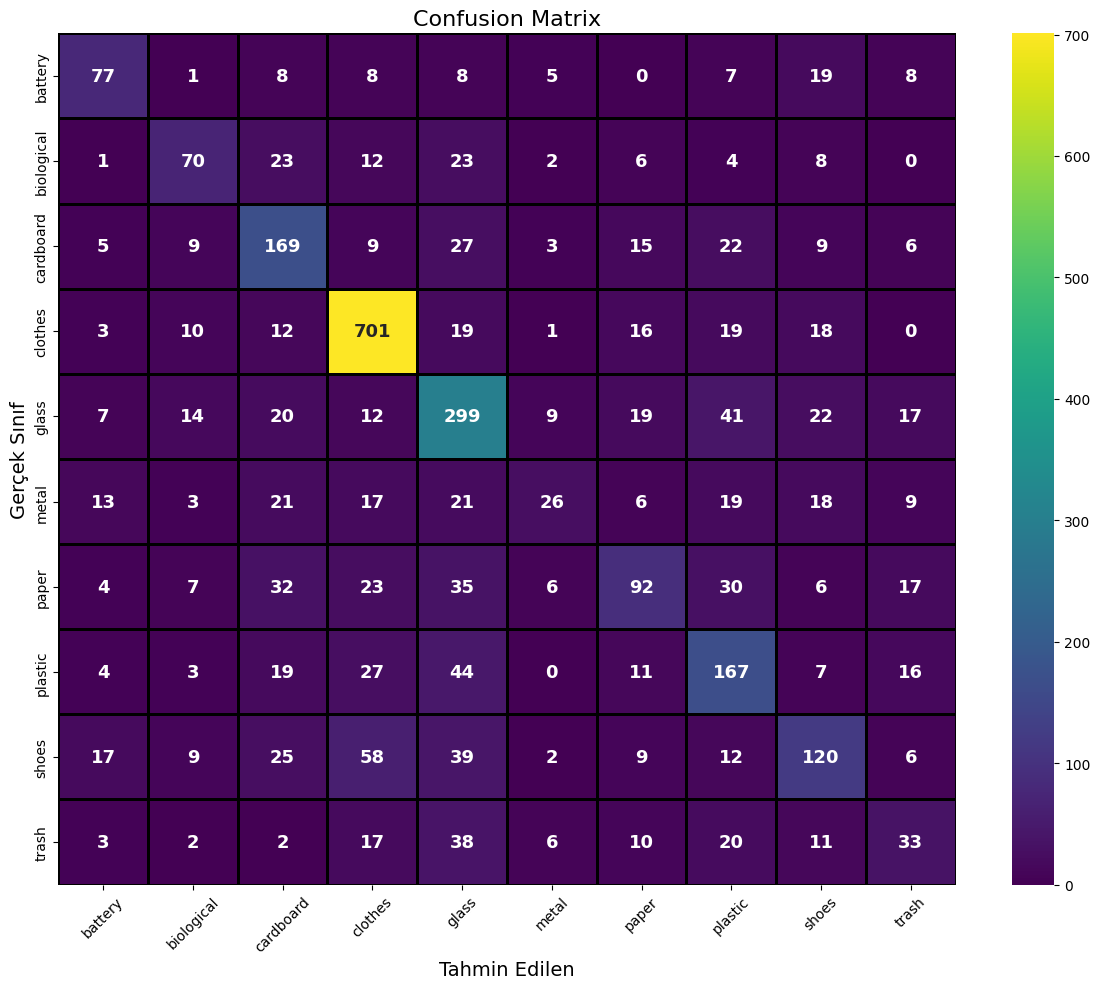

<Figure size 1200x1200 with 0 Axes>

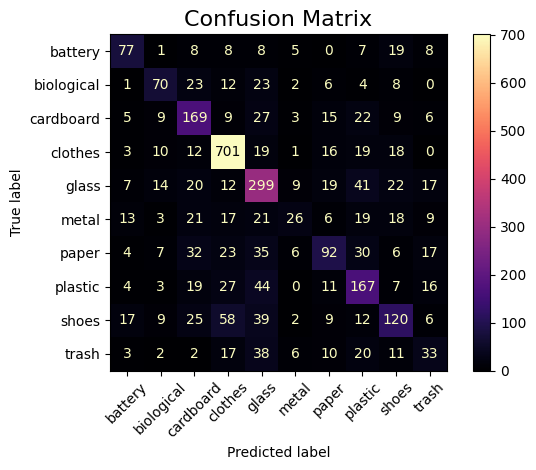

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

if 'test_preds' not in locals() or 'test_labels' not in locals():
    print("Lütfen önce test tahminlerini yapan hücreyi çalıştırın!")
else:
    
    cm = confusion_matrix(test_labels, test_preds)
    
    plt.figure(figsize=(12, 10))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', linewidths=1, linecolor='black',
                xticklabels=classes, yticklabels=classes, annot_kws={"size": 13, "weight": "bold"})
    
    plt.title('Confusion Matrix', fontsize=16)
    plt.xlabel('Tahmin Edilen', fontsize=14)
    plt.ylabel('Gerçek Sınıf', fontsize=14)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('grafik_cm_renkli.png', dpi=300)
    plt.show()

    
    plt.figure(figsize=(12, 12))
    
    disp = ConfusionMatrixDisplay.from_predictions(
        test_labels, 
        test_preds, 
        display_labels=classes, 
        cmap='magma', 
        xticks_rotation=45,
        values_format='d',
        colorbar=True
    )
    
    plt.title('Confusion Matrix', fontsize=16)
   
    plt.tight_layout()
    plt.savefig('grafik_cm_sklearn.png', dpi=300)
    plt.show()


In [28]:
print("-" * 50)
print("MODEL MİMARİSİ ")
print("-" * 50)
print(final_model)
print("-" * 50)

print("\nKatman Detayları:")
for name, layer in final_model.named_modules():
    if isinstance(layer, torch.nn.Linear):
        print(f"📍 {name}: Giriş={layer.in_features}, Çıkış={layer.out_features}, Bias={layer.bias is not None}")
    elif isinstance(layer, torch.nn.Dropout):
        print(f"🔻 {name}: Dropout Oranı={layer.p}")
    elif isinstance(layer, torch.nn.ReLU):
        print(f"🔄 {name}: Aktivasyon (ReLU)")

--------------------------------------------------
MODEL MİMARİSİ 
--------------------------------------------------
ShallowMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=150528, out_features=2048, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=2048, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)
--------------------------------------------------

Katman Detayları:
📍 layers.0: Giriş=150528, Çıkış=2048, Bias=True
🔄 layers.1: Aktivasyon (ReLU)
🔻 layers.2: Dropout Oranı=0.3
📍 layers.3: Giriş=2048, Çıkış=512, Bias=True
🔄 layers.4: Aktivasyon (ReLU)
🔻 layers.5: Dropout Oranı=0.3
📍 layers.6: Giriş=512, Çıkış=128, Bias=True
🔄 layers.7: Aktivasyon (ReLU)
🔻 layers.8: Dropout 

C:\Users\user\AppData\Local\Temp\ipykernel_2896\3295308578.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=f1_scores, palette='Blues_d')


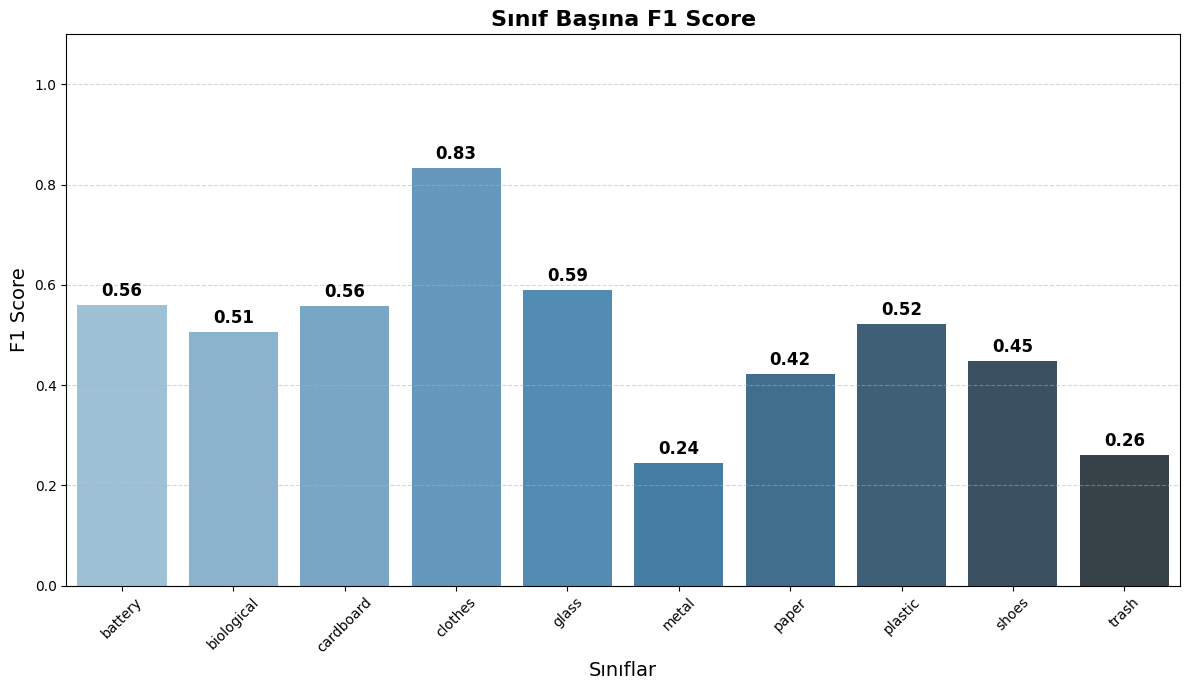

Grafik 'grafik_sinif_f1_score.png' olarak kaydedildi.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


if 'test_preds' not in locals() or 'test_labels' not in locals():
    print("HATA: Lütfen önce test tahminlerini (test_preds) hesaplayan hücreyi çalıştırın.")
else:
    
    report = classification_report(test_labels, test_preds, target_names=classes, output_dict=True)
    
    
    class_names = []
    f1_scores = []
    
    for cls in classes:
        class_names.append(cls)
        f1_scores.append(report[cls]['f1-score'])

    
    plt.figure(figsize=(12, 7))
    
    
    ax = sns.barplot(x=class_names, y=f1_scores, palette='Blues_d')
    
    
    plt.title('Sınıf Başına F1 Score', fontsize=16, fontweight='bold')
    plt.ylabel('F1 Score', fontsize=14)
    plt.xlabel('Sınıflar', fontsize=14)
    plt.ylim(0, 1.1) 
    plt.xticks(rotation=45) 
    plt.grid(axis='y', linestyle='--', alpha=0.5)

   
    for i, p in enumerate(ax.patches):
        
        height = p.get_height()
        
        ax.text(p.get_x() + p.get_width()/2., height + 0.01, 
                f'{height:.2f}', 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

    plt.tight_layout()
    plt.savefig('grafik_sinif_f1_score.png', dpi=300)
    plt.show()

    print("Grafik 'grafik_sinif_f1_score.png' olarak kaydedildi.")